In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [2]:
df = pd.read_csv('merged_data.csv')
print(df.shape)
print(df.columns.tolist())
df.head(5)

(848, 17)
['id', 'name', 'type1', 'type2', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'is_legendary', 'is_mythical', 'dex_number', 'tier', 'abilities', 'types', 'is_fully_evolved']


,id,name,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,is_legendary,is_mythical,dex_number,tier,abilities,types,is_fully_evolved
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,False,False,1,LC,"Overgrow, Chlorophyll","Grass, Poison",False
1,2,ivysaur,grass,poison,60,62,63,80,80,60,False,False,2,NFE,"Overgrow, Chlorophyll","Grass, Poison",False
2,3,venusaur,grass,poison,80,82,83,100,100,80,False,False,3,ZU,"Overgrow, Chlorophyll","Grass, Poison",True
3,4,charmander,fire,NaN,39,52,43,60,50,65,False,False,4,LC,"Blaze, Solar Power",Fire,False
4,5,charmeleon,fire,NaN,58,64,58,80,65,80,False,False,5,NFE,"Blaze, Solar Power",Fire,False


In [5]:
print(df.dtypes)
print(df.isnull().sum())

id                   int64
name                object
type1               object
type2               object
hp                   int64
attack               int64
defense              int64
sp_attack            int64
sp_defense           int64
speed                int64
is_legendary          bool
is_mythical           bool
dex_number           int64
tier                object
abilities           object
types               object
is_fully_evolved      bool
dtype: object
id                    0
name                  0
type1                 0
type2               397
hp                    0
attack                0
defense               0
sp_attack             0
sp_defense            0
speed                 0
is_legendary          0
is_mythical           0
dex_number            0
tier                  0
abilities             0
types                 0
is_fully_evolved      0
dtype: int64


In [7]:
df['type2'] = df['type2'].fillna('None')

# Add classification column
def classify(row):
    if row['is_mythical']:
        return 'Mythical'
    elif row['is_legendary']:
        return 'Legendary'
    else:
        return 'Regular'

df['classification'] = df.apply(classify, axis=1)

# Add base stat total and power score
df['base_stat_total'] = df['hp'] + df['attack'] + df['defense'] + df['sp_attack'] + df['sp_defense'] + df['speed']
df['power_score'] = (
    df['attack'] * 0.25 +
    df['sp_attack'] * 0.25 +
    df['speed'] * 0.25 +
    df['defense'] * 0.125 +
    df['sp_defense'] * 0.125 +
    df['hp'] * 0.10
)

print(df.shape)
df.head(5)

(848, 20)


,id,name,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,is_legendary,is_mythical,dex_number,tier,abilities,types,is_fully_evolved,classification,base_stat_total,power_score
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,False,False,1,LC,"Overgrow, Chlorophyll","Grass, Poison",False,Regular,318,58.500
1,2,ivysaur,grass,poison,60,62,63,80,80,60,False,False,2,NFE,"Overgrow, Chlorophyll","Grass, Poison",False,Regular,405,74.375
2,3,venusaur,grass,poison,80,82,83,100,100,80,False,False,3,ZU,"Overgrow, Chlorophyll","Grass, Poison",True,Regular,525,96.375
3,4,charmander,fire,None,39,52,43,60,50,65,False,False,4,LC,"Blaze, Solar Power",Fire,False,Regular,309,59.775
4,5,charmeleon,fire,None,58,64,58,80,65,80,False,False,5,NFE,"Blaze, Solar Power",Fire,False,Regular,405,77.175


In [9]:
print(df['tier'].value_counts())
print(f"\nClassification breakdown:")
print(df['classification'].value_counts())

tier
LC      224
ZU      175
NFE     109
Uber     70
PU       47
NU       47
OU       41
RU       41
UU       38
UUBL     17
RUBL     15
NUBL     11
ZUBL      6
PUBL      5
AG        2
Name: count, dtype: int64

Classification breakdown:
classification
Regular      723
Legendary     84
Mythical      41
Name: count, dtype: int64


In [11]:
type_colors = {
    'fire': '#F08030',
    'water': '#6890F0',
    'grass': '#78C850',
    'electric': '#F8D030',
    'psychic': '#F85888',
    'ice': '#98D8D8',
    'dragon': '#7038F8',
    'dark': '#705848',
    'fairy': '#EE99AC',
    'fighting': '#C03028',
    'flying': '#A890F0',
    'poison': '#A040A0',
    'ground': '#E0C068',
    'rock': '#B8A038',
    'bug': '#A8B820',
    'ghost': '#705898',
    'steel': '#B8B8D0',
    'normal': '#A8A878',
}

tier_colors = {
    'AG': '#FF0000',
    'Uber': '#FF6600',
    'OU': '#FFD700',
    'UUBL': '#90EE90',
    'UU': '#00CC00',
    'RUBL': '#00FFFF',
    'RU': '#0099FF',
    'NUBL': '#9370DB',
    'NU': '#800080',
    'PUBL': '#FF69B4',
    'PU': '#FF1493',
    'ZUBL': '#A0522D',
    'ZU': '#8B4513',
    'NFE': '#808080',
    'LC': '#C0C0C0',
    'Untiered': '#FFFFFF'
}

stat_colors = {
    'hp': '#FF5959',
    'attack': '#F5AC78',
    'defense': '#FAE078',
    'sp_attack': '#9DB7F5',
    'sp_defense': '#A7DB8D',
    'speed': '#FA92B2'
}

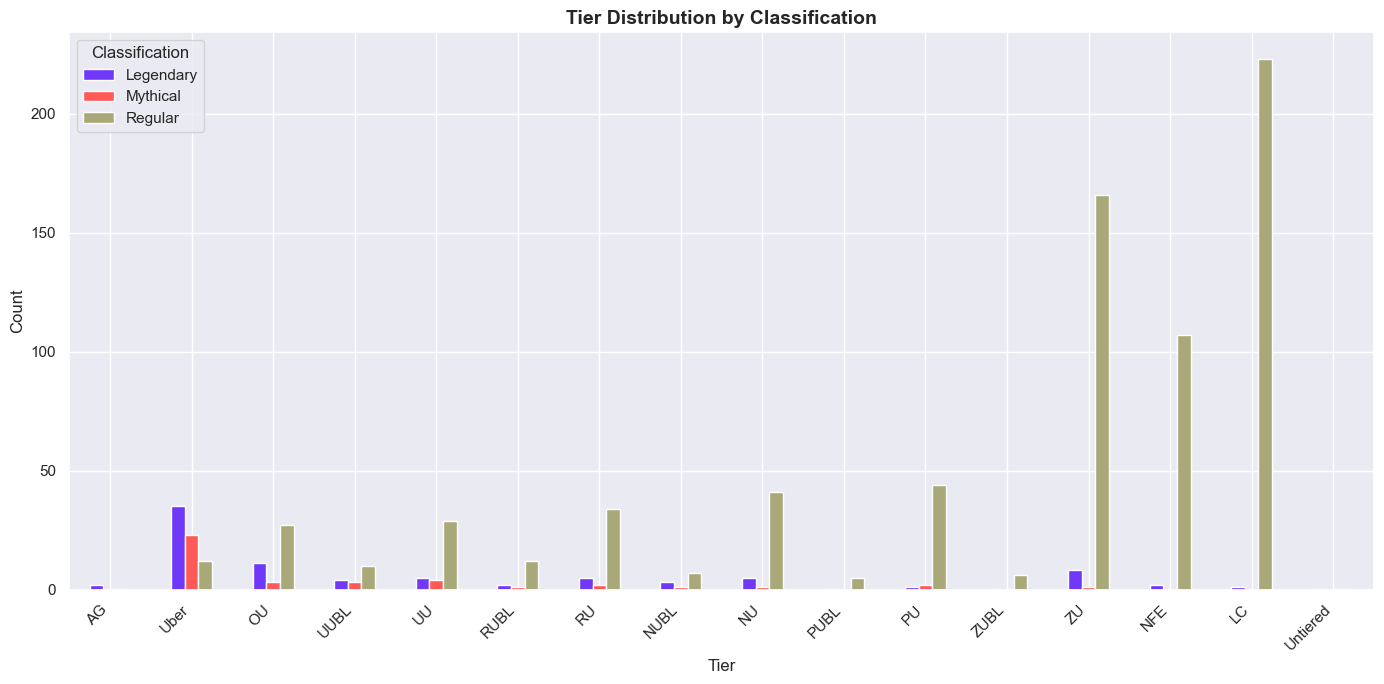

In [13]:
tier_order = ['AG', 'Uber', 'OU', 'UUBL', 'UU', 'RUBL', 'RU', 'NUBL', 'NU', 'PUBL', 'PU', 'ZUBL', 'ZU', 'NFE', 'LC', 'Untiered']

tier_counts = df.groupby(['tier', 'classification']).size().unstack(fill_value=0)
tier_counts = tier_counts.reindex(tier_order)

tier_counts.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#7038F8', '#FF5959', '#A8A878']
)
plt.title('Tier Distribution by Classification', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Classification')
plt.tight_layout()
plt.show()

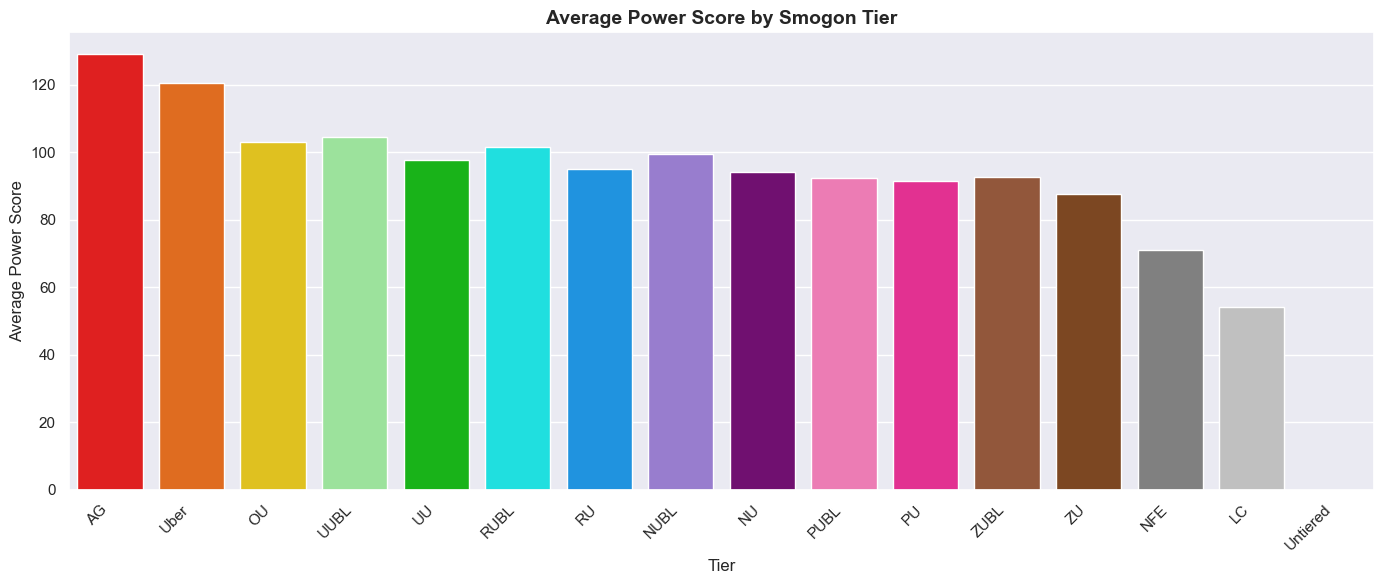

In [15]:
tier_order = ['AG', 'Uber', 'OU', 'UUBL', 'UU', 'RUBL', 'RU', 'NUBL', 
              'NU', 'PUBL', 'PU', 'ZUBL', 'ZU', 'NFE', 'LC', 'Untiered']

tier_avg = df.groupby('tier')['power_score'].mean().reindex(tier_order)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=tier_avg.index,
    y=tier_avg.values,
    hue=tier_avg.index,
    legend=False,
    palette=tier_colors
)
plt.title('Average Power Score by Smogon Tier', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('Average Power Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

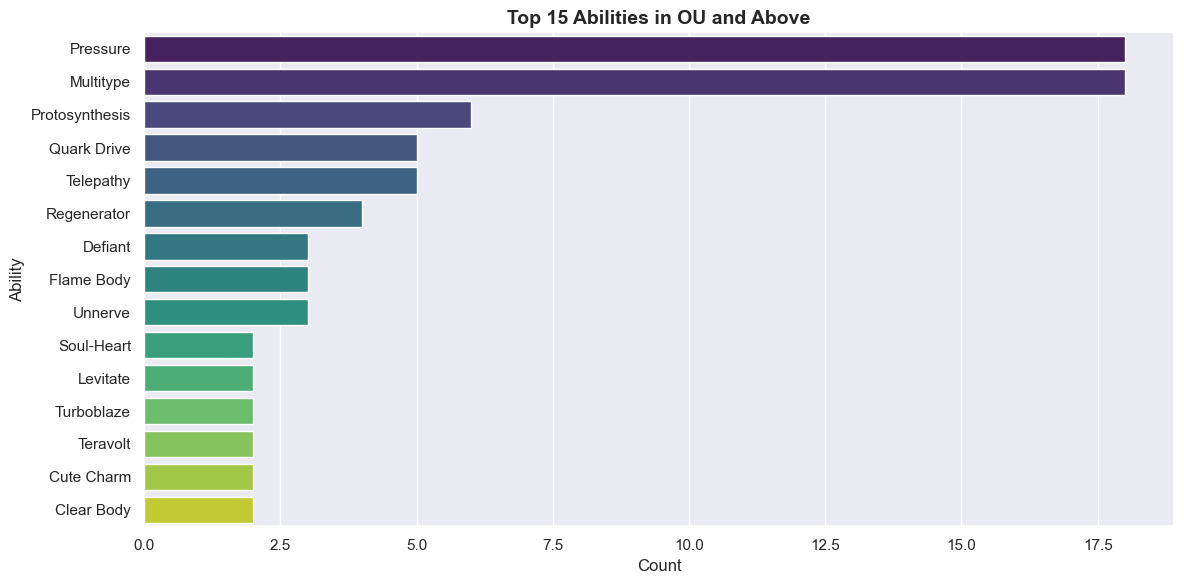

In [17]:
ou_above = df[df['tier'].isin(['AG', 'Uber', 'OU'])]

all_abilities = ou_above['abilities'].str.split(', ').explode()
top_abilities = all_abilities.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_abilities.values,
    y=top_abilities.index,
    hue=top_abilities.index,
    legend=False,
    palette='viridis'
)
plt.title('Top 15 Abilities in OU and Above', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Ability')
plt.tight_layout()
plt.show()

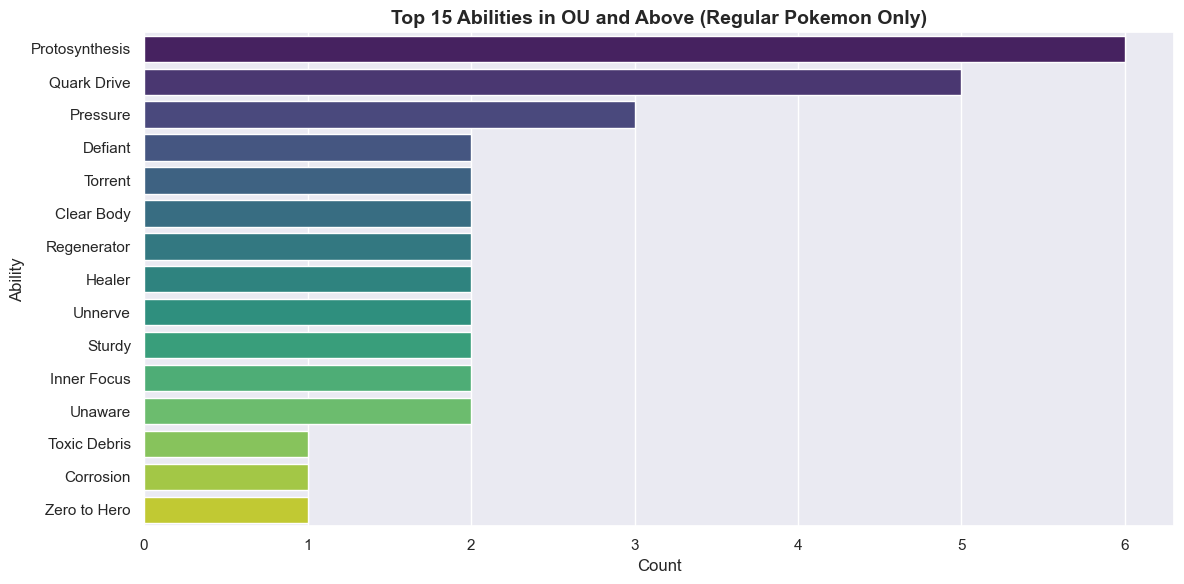

In [19]:
ou_regular = df[
    (df['tier'].isin(['AG', 'Uber', 'OU'])) & 
    (df['classification'] == 'Regular')
]

all_abilities = ou_regular['abilities'].str.split(', ').explode()
top_abilities = all_abilities.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_abilities.values,
    y=top_abilities.index,
    hue=top_abilities.index,
    legend=False,
    palette='viridis'
)
plt.title('Top 15 Abilities in OU and Above (Regular Pokemon Only)', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Ability')
plt.tight_layout()
plt.show()

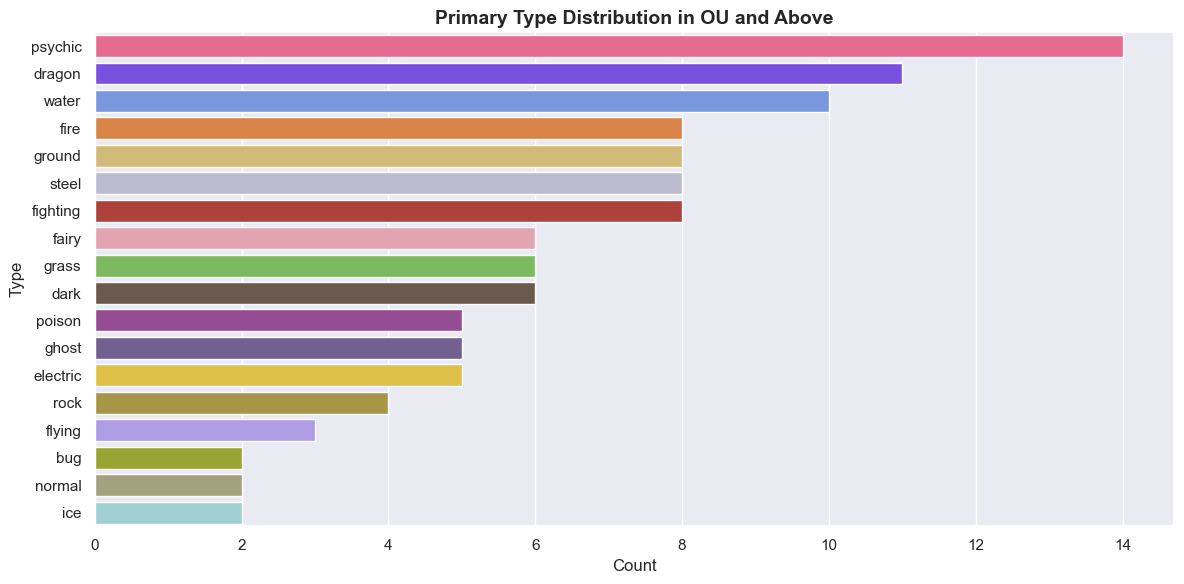

In [21]:
ou_above = df[df['tier'].isin(['AG', 'Uber', 'OU'])]

type_counts = ou_above['type1'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=type_counts.values,
    y=type_counts.index,
    hue=type_counts.index,
    legend=False,
    palette=type_colors
)
plt.title('Primary Type Distribution in OU and Above', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

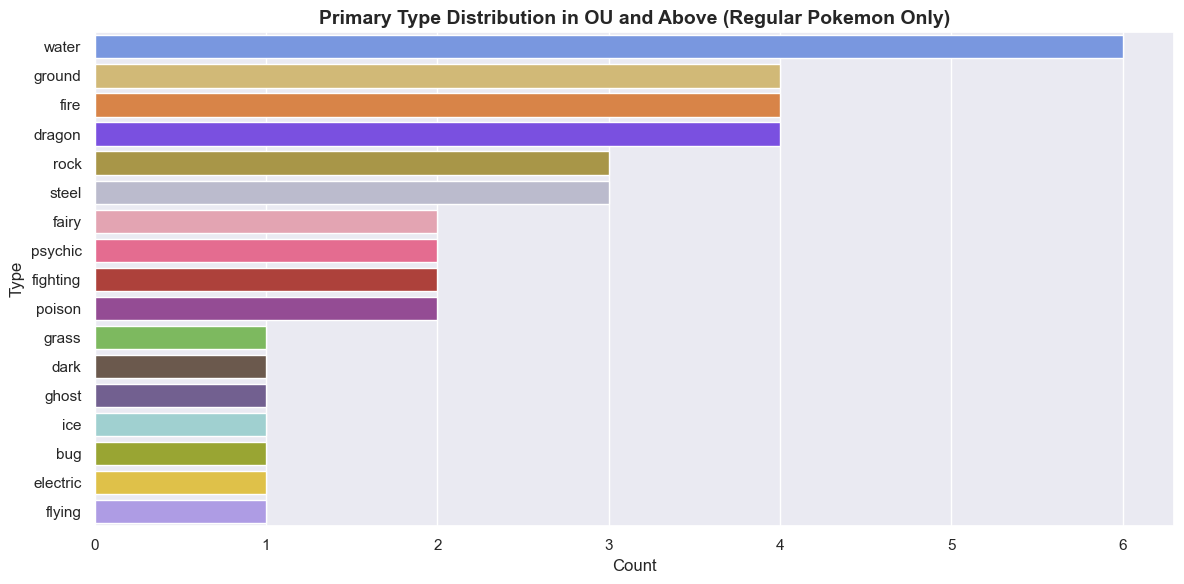

In [23]:
ou_regular = df[
    (df['tier'].isin(['AG', 'Uber', 'OU'])) &
    (df['classification'] == 'Regular')
]

type_counts = ou_regular['type1'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=type_counts.values,
    y=type_counts.index,
    hue=type_counts.index,
    legend=False,
    palette=type_colors
)
plt.title('Primary Type Distribution in OU and Above (Regular Pokemon Only)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

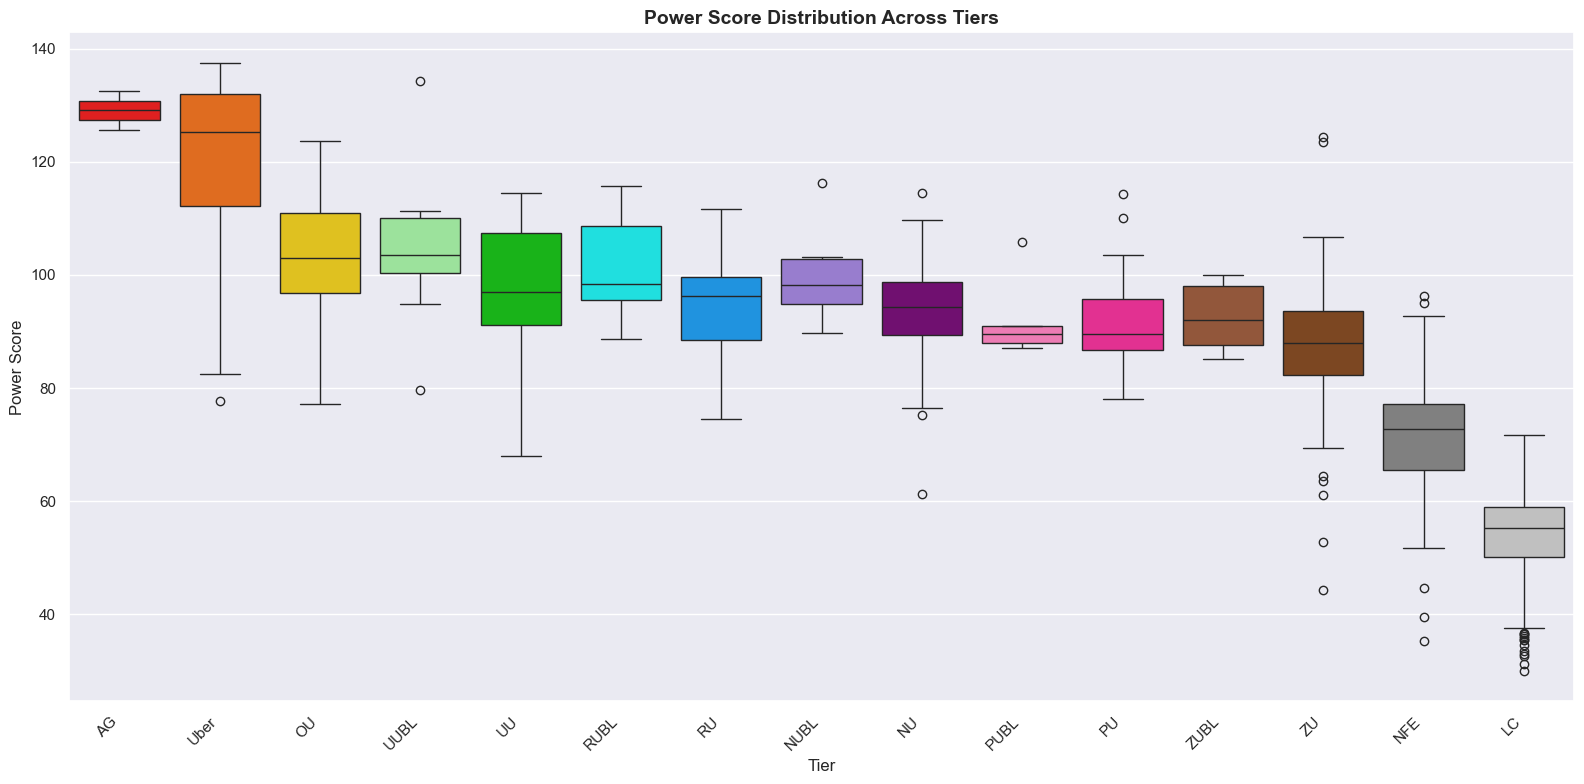

In [25]:
tier_order = ['AG', 'Uber', 'OU', 'UUBL', 'UU', 'RUBL', 'RU', 
              'NUBL', 'NU', 'PUBL', 'PU', 'ZUBL', 'ZU', 'NFE', 'LC']

df_filtered = df[df['tier'].isin(tier_order)]

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_filtered,
    x='tier',
    y='power_score',
    order=tier_order,
    hue='tier',
    palette=tier_colors,
    legend=False
)
plt.title('Power Score Distribution Across Tiers', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('Power Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()